In [2]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB  = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST     = os.getenv("HOST")
PORT     = os.getenv("PORT")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

db = create_engine(url)

In [3]:
query_string = """
SELECT d.*, s.date, s.price
FROM eda.king_county_house_details d
JOIN (
    SELECT DISTINCT ON (house_id) house_id, date, price
    FROM eda.king_county_house_sales
    ORDER BY house_id, date DESC
) s ON d.id = s.house_id
"""

df = pd.read_sql(query_string, db)
df.shape   # should show (21420, ...)

(21420, 21)

In [4]:
df.to_csv("data/kc_house_data.csv", index=False)

In [5]:
# 1. Overall price picture
df["price"].describe()

count    2.142000e+04
mean     5.418614e+05
std      3.675569e+05
min      7.800000e+04
25%      3.249500e+05
50%      4.505500e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [6]:
# 2. Which zipcodes are the most expensive ("rich" neighborhoods) and how many houses are in each
zip_stats = df.groupby("zipcode")["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
zip_stats.head(15)

,mean,median,count
zipcode,,,
98039,2.187551e+06,1910000.0,49
98004,1.355972e+06,1150000.0,315
98040,1.194874e+06,993750.0,282
98112,1.096934e+06,917500.0,268
98102,8.996077e+05,710000.0,104
98109,8.800778e+05,736000.0,109
98105,8.632289e+05,675000.0,229
98006,8.581498e+05,760184.5,490
98119,8.497148e+05,744975.0,184


In [7]:
# 3. Waterfront price premium
df.groupby("waterfront")["price"].agg(["mean", "median", "count"])

,mean,median,count
waterfront,,,
0.0,5.341192e+05,450000.0,18914
1.0,1.717215e+06,1510000.0,146


In [8]:
# 4. Grade / condition vs price
df.groupby("grade")["price"].mean()
df.groupby("condition")["price"].mean()

condition
1    349480.357143
2    334005.487654
3    543939.561223
4    522310.528974
5    613289.410788
Name: price, dtype: float64

In [9]:
# 5. Renovated vs not-renovated price difference
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)
df.groupby("is_renovated")["price"].mean()

is_renovated
0    532248.478155
1    577493.344979
Name: price, dtype: float64

In [10]:
# 6. Sale timing — is there a "best month" to sell?
df["date"] = pd.to_datetime(df["date"])
df["sale_month"] = df["date"].dt.month
df.groupby("sale_month")["price"].mean()

sale_month
1     527490.298047
2     508947.491158
3     544057.683200
4     562215.615074
5     551732.096532
6     558833.807531
7     547008.847279
8     539822.591218
9     533712.206640
10    541980.481122
11    523841.335244
12    526173.769547
Name: price, dtype: float64

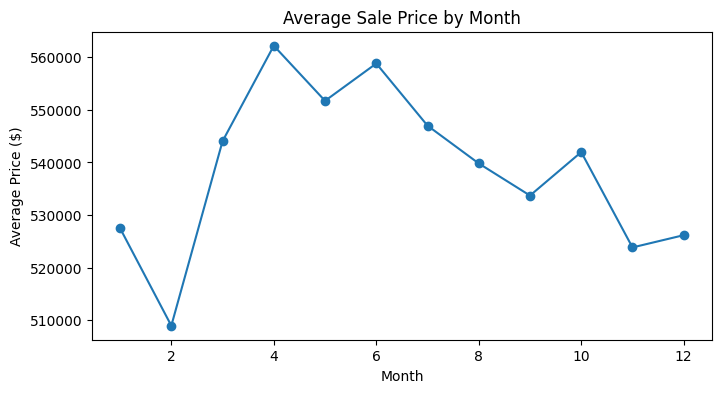

In [11]:
import matplotlib.pyplot as plt

df.groupby("sale_month")["price"].mean().plot(kind="line", marker="o", figsize=(8,4))
plt.title("Average Sale Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price ($)")
plt.show()

In [14]:
df.columns
df["date"].dtype

dtype('<M8[s]')

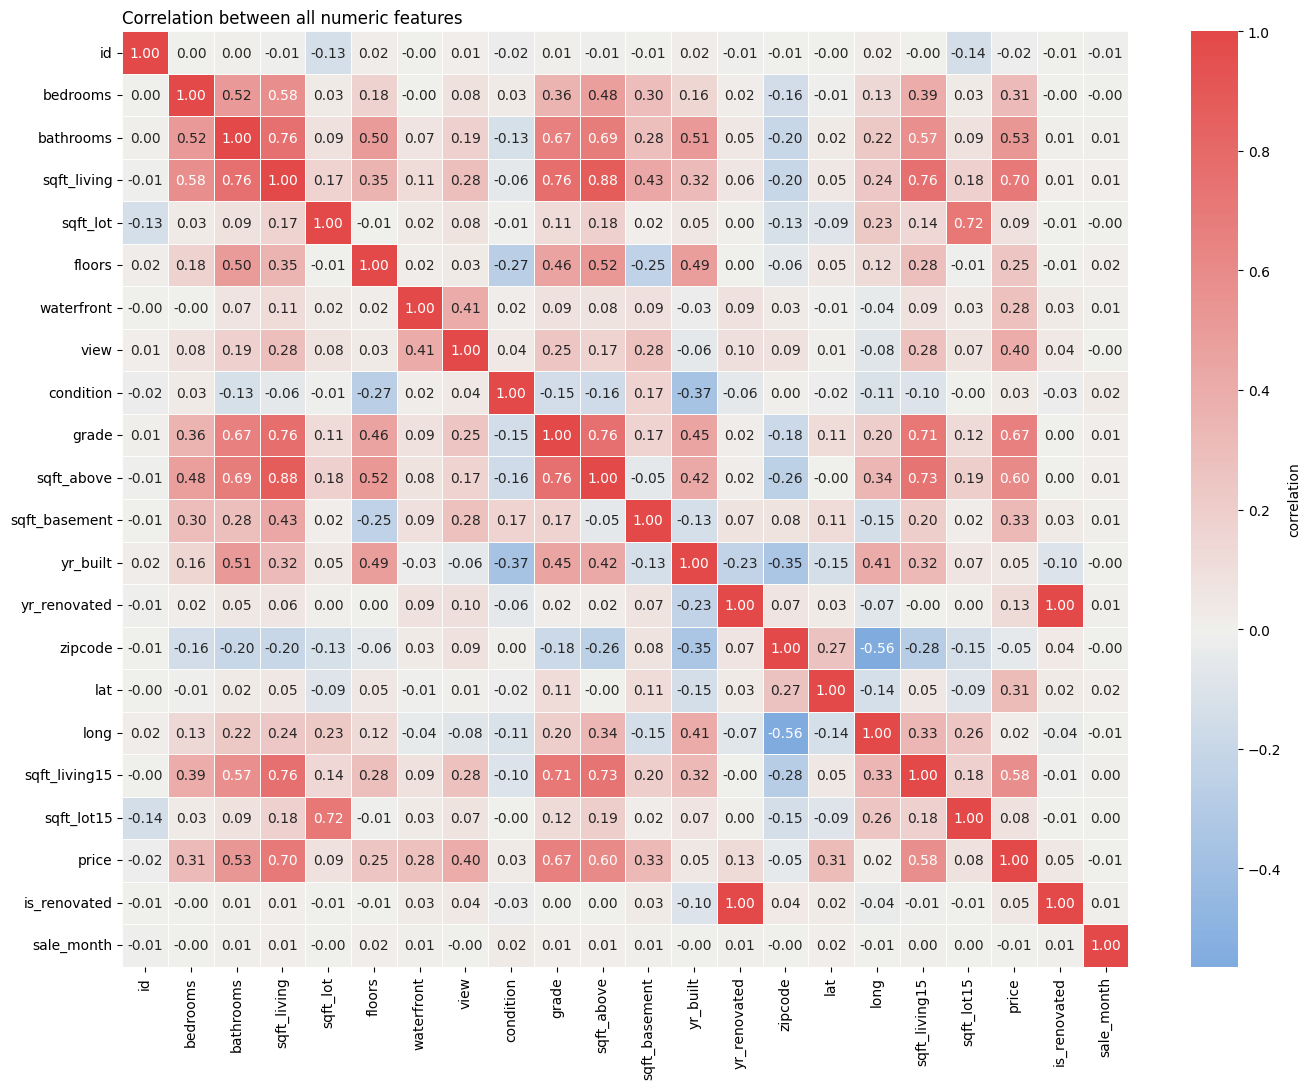

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

# diverging blue <-> red, gray at zero (no correlation)
cmap = LinearSegmentedColormap.from_list(
    "diverging", ["#2a78d6", "#f0efec", "#e34948"]
)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0,
            linewidths=0.5, linecolor="#fcfcfb",
            cbar_kws={"label": "correlation"})
plt.title("Correlation between all numeric features", loc="left")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

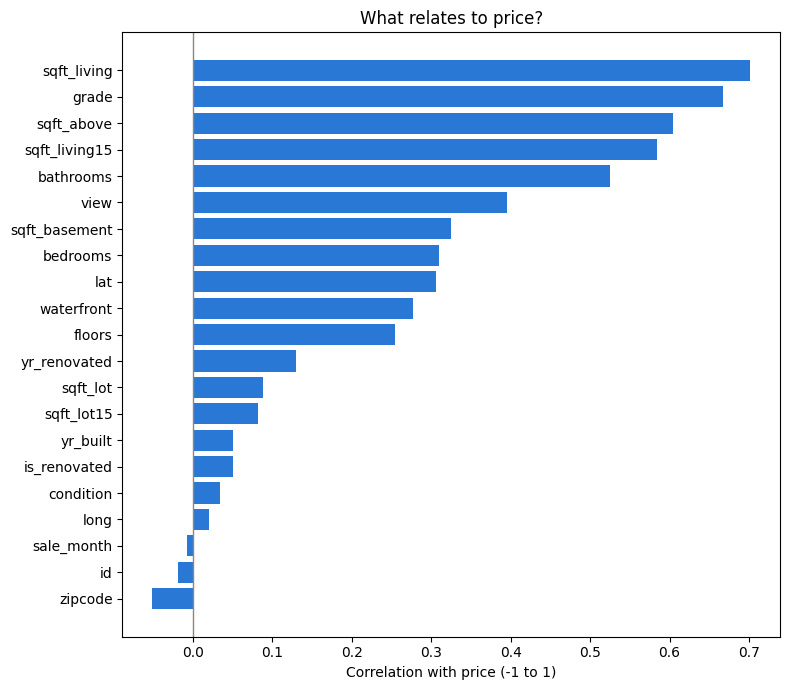

In [16]:
import matplotlib.pyplot as plt

corr_with_price = df.select_dtypes(include="number").corr()["price"].drop("price").sort_values()

plt.figure(figsize=(8, 7))
plt.barh(corr_with_price.index, corr_with_price.values, color="#2a78d6")
plt.axvline(0, color="#898781", linewidth=1)
plt.title("What relates to price?")
plt.xlabel("Correlation with price (-1 to 1)")
plt.tight_layout()
plt.show()

In [18]:
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.00,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.00,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.00,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.50,1260.0,7248.0,1.5,NaN,0.0,5,7,...,NaN,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,1,9
4,1003000175,3.0,1.00,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,993002177,3.0,2.50,1380.0,1547.0,3.0,0.0,0.0,3,8,...,NaN,98103,47.6908,-122.341,1380.0,1465.0,2015-05-06,345000.0,1,5
21416,993002225,3.0,2.25,1520.0,1245.0,3.0,NaN,0.0,3,8,...,0.0,98103,47.6907,-122.340,1520.0,1470.0,2014-06-23,405000.0,0,6
21417,993002247,3.0,2.25,1550.0,1469.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6911,-122.341,1520.0,1465.0,2014-07-16,430000.0,0,7
21418,993002325,2.0,1.50,950.0,4625.0,1.0,0.0,0.0,4,7,...,NaN,98103,47.6912,-122.340,1440.0,4625.0,2014-06-23,430000.0,1,6


In [17]:
df["grade"].value_counts().sort_index()

grade
3        1
4       27
5      234
6     1995
7     8889
8     6041
9     2606
10    1130
11     396
12      88
13      13
Name: count, dtype: int64

In [19]:
GRADE_CUTOFF = 10

jennifer_segment = df[(df["waterfront"] == 1) & (df["grade"] >= GRADE_CUTOFF)]
print("Matching houses:", jennifer_segment.shape[0])
jennifer_segment[["price", "zipcode", "grade", "is_renovated"]].describe(include="all")

Matching houses: 57


,price,zipcode,grade,is_renovated
count,5.700000e+01,57.000000,57.000000,57.000000
mean,2.687719e+06,98073.245614,10.684211,0.280702
std,1.133780e+06,56.300939,0.759650,0.453336
min,3.800000e+05,98004.000000,10.000000,0.000000
25%,1.880000e+06,98033.000000,10.000000,0.000000
50%,2.510000e+06,98056.000000,11.000000,0.000000
75%,3.280000e+06,98116.000000,11.000000,1.000000
max,7.060000e+06,98199.000000,12.000000,1.000000


In [20]:
jennifer_segment.sort_values("price").head(3)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
16261,7631800110,3.0,2.50,1980.0,17342.0,2.0,1.0,4.0,3,10,...,0.0,98166,47.4551,-122.373,2060.0,17313.0,2014-09-18,380000.0,0,9
19392,8917100020,3.0,1.50,2170.0,16600.0,1.0,1.0,2.0,3,10,...,0.0,98052,47.6307,-122.088,3130.0,13875.0,2014-06-06,1150000.0,0,6
7608,3342104046,4.0,2.25,2890.0,18226.0,3.0,1.0,4.0,3,10,...,0.0,98056,47.5169,-122.209,2870.0,11151.0,2014-07-08,1570000.0,0,7


In [21]:
jennifer_segment["zipcode"].value_counts()

zipcode
98040    8
98008    7
98166    5
98075    4
98074    3
98056    3
98155    3
98105    3
98033    2
98052    2
98027    2
98118    2
98034    2
98006    2
98199    1
98039    1
98115    1
98144    1
98116    1
98028    1
98136    1
98178    1
98004    1
Name: count, dtype: int64

In [24]:
print(dir())

['DATABASE', 'GRADE_CUTOFF', 'HOST', 'In', 'LinearSegmentedColormap', 'Out', 'PASSWORD', 'PORT', 'URL', 'USER_DB', '_', '_10', '_12', '_13', '_14', '_17', '_18', '_19', '_20', '_21', '_3', '_5', '_6', '_7', '_8', '_9', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'cmap', 'corr', 'corr_with_price', 'create_engine', 'db', 'df', 'exit', 'get_ipython', 'jennifer_segment', 'load_dotenv', 'numeric_cols', 'open', 'os', 'pd', 'plt', 'query_string', 'quit', 'sns', 'url', 'zip_stats']


In [25]:
df.groupby("zipcode")["grade"].mean().sort_values(ascending=False).head(10)

zipcode
98039    9.612245
98075    9.011173
98040    8.960993
98006    8.783673
98077    8.775510
98074    8.719540
98004    8.688889
98005    8.488095
98112    8.440299
98029    8.393750
Name: grade, dtype: float64

In [26]:
df["zipcode"].nunique()

70

In [27]:
df.groupby("zipcode")["grade"].mean().sort_values(ascending=False)   # no .head() — shows every zipcode, ranked

zipcode
98039    9.612245
98075    9.011173
98040    8.960993
98006    8.783673
98077    8.775510
           ...   
98106    6.875758
98146    6.836299
98178    6.829457
98002    6.695431
98168    6.522727
Name: grade, Length: 70, dtype: float64

In [28]:
df["waterfront"].value_counts(dropna=False)

waterfront
0.0    18914
NaN     2360
1.0      146
Name: count, dtype: int64

In [29]:
df["is_renovated"].value_counts(dropna=False)
df["yr_renovated"].isnull().sum()

np.int64(3811)

In [30]:
df_sales = pd.read_sql("SELECT * FROM eda.king_county_house_sales", db)
resold = df_sales.groupby("house_id").filter(lambda g: len(g) > 1)
resold_sorted = resold.sort_values(["house_id", "date"])
resold_sorted["pct_change"] = resold_sorted.groupby("house_id")["price"].pct_change() * 100
resold_changes = resold_sorted.dropna(subset=["pct_change"])
resold_changes["pct_change"].describe()

count    177.000000
mean      56.436939
std       46.699391
min       -5.405405
25%       23.108384
50%       54.320988
75%       73.870968
max      321.800948
Name: pct_change, dtype: float64

In [31]:
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

In [32]:
df["yr_renovated"] = df["yr_renovated"].fillna(0)
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

# recheck: should now be 0
df["yr_renovated"].isnull().sum()

# recompute the renovation premium with corrected data
df.groupby("is_renovated")["price"].mean()

is_renovated
0    533658.983704
1    771086.497297
Name: price, dtype: float64

In [33]:
df["is_renovated"].value_counts()

is_renovated
0    20680
1      740
Name: count, dtype: int64

In [34]:
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.00,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.00,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.00,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.50,1260.0,7248.0,1.5,NaN,0.0,5,7,...,0.0,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,0,9
4,1003000175,3.0,1.00,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,993002177,3.0,2.50,1380.0,1547.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6908,-122.341,1380.0,1465.0,2015-05-06,345000.0,0,5
21416,993002225,3.0,2.25,1520.0,1245.0,3.0,NaN,0.0,3,8,...,0.0,98103,47.6907,-122.340,1520.0,1470.0,2014-06-23,405000.0,0,6
21417,993002247,3.0,2.25,1550.0,1469.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6911,-122.341,1520.0,1465.0,2014-07-16,430000.0,0,7
21418,993002325,2.0,1.50,950.0,4625.0,1.0,0.0,0.0,4,7,...,0.0,98103,47.6912,-122.340,1440.0,4625.0,2014-06-23,430000.0,0,6


In [35]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'is_renovated',
       'sale_month'],
      dtype='str')

In [36]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.0,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.0,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.0,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.5,1260.0,7248.0,1.5,NaN,0.0,5,7,...,0.0,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,0,9
4,1003000175,3.0,1.0,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12


In [37]:
df.dtypes

id                       int64
bedrooms               float64
bathrooms              float64
sqft_living            float64
sqft_lot               float64
floors                 float64
waterfront             float64
view                   float64
condition                int64
grade                    int64
sqft_above             float64
sqft_basement          float64
yr_built                 int64
yr_renovated           float64
zipcode                  int64
lat                    float64
long                   float64
sqft_living15          float64
sqft_lot15             float64
date             datetime64[s]
price                  float64
is_renovated             int64
sale_month               int32
dtype: object

In [39]:
df["bathrooms"].describe()

count    21420.000000
mean         2.118429
std          0.768720
min          0.500000
25%          1.750000
50%          2.250000
75%          2.500000
max          8.000000
Name: bathrooms, dtype: float64

In [ ]:
df["bathrooms"].isnull().sum()


np.int64(0)